In [1]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd

In [6]:
from google.colab import files

my_dataset = pd.read_csv('lebron_shot_data.csv')

In [7]:
df = pd.read_csv('lebron_shot_data.csv')

In [8]:
df.head()

,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,EVENT_TYPE,...,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM,SEASON
0,20300014,20,2544,LeBron James,1610612739,Cleveland Cavaliers,1,8,56,Made Shot,...,8-16 ft.,15,158,0,1,1,20031029,SAC,CLE,2003-04
1,20300014,28,2544,LeBron James,1610612739,Cleveland Cavaliers,1,7,44,Made Shot,...,8-16 ft.,13,-131,2,1,1,20031029,SAC,CLE,2003-04
2,20300014,35,2544,LeBron James,1610612739,Cleveland Cavaliers,1,7,1,Made Shot,...,16-24 ft.,16,163,5,1,1,20031029,SAC,CLE,2003-04
3,20300014,39,2544,LeBron James,1610612739,Cleveland Cavaliers,1,6,29,Missed Shot,...,8-16 ft.,14,-118,92,1,0,20031029,SAC,CLE,2003-04
4,20300014,54,2544,LeBron James,1610612739,Cleveland Cavaliers,1,4,48,Made Shot,...,Less Than 8 ft.,5,54,22,1,1,20031029,SAC,CLE,2003-04


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29311 entries, 0 to 29310
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   GAME_ID              29311 non-null  int64 
 1   GAME_EVENT_ID        29311 non-null  int64 
 2   PLAYER_ID            29311 non-null  int64 
 3   PLAYER_NAME          29311 non-null  object
 4   TEAM_ID              29311 non-null  int64 
 5   TEAM_NAME            29311 non-null  object
 6   PERIOD               29311 non-null  int64 
 7   MINUTES_REMAINING    29311 non-null  int64 
 8   SECONDS_REMAINING    29311 non-null  int64 
 9   EVENT_TYPE           29311 non-null  object
 10  ACTION_TYPE          29311 non-null  object
 11  SHOT_TYPE            29311 non-null  object
 12  SHOT_ZONE_BASIC      29311 non-null  object
 13  SHOT_ZONE_AREA       29311 non-null  object
 14  SHOT_ZONE_RANGE      29311 non-null  object
 15  SHOT_DISTANCE        29311 non-null  int64 
 16  LOC_

In [10]:
df.describe()

,GAME_ID,GAME_EVENT_ID,PLAYER_ID,TEAM_ID,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE
count,2.931100e+04,29311.000000,29311.0,2.931100e+04,29311.000000,29311.000000,29311.000000,29311.000000,29311.000000,29311.000000,29311.0,29311.000000,2.931100e+04
mean,2.122812e+07,275.322882,2544.0,1.610613e+09,2.513561,5.044352,28.290676,11.708744,-9.263075,80.572208,1.0,0.506192,2.012953e+07
std,6.048328e+05,172.893844,0.0,4.175265e+00,1.152725,3.458327,17.593051,10.336964,102.846589,91.731562,0.0,0.499970,6.033555e+04
min,2.030001e+07,1.000000,2544.0,1.610613e+09,1.000000,0.000000,0.000000,0.000000,-248.000000,-44.000000,1.0,0.000000,2.003103e+07
25%,2.070056e+07,116.000000,2544.0,1.610613e+09,1.000000,2.000000,13.000000,1.000000,-68.000000,6.000000,1.0,0.000000,2.008012e+07
50%,2.120051e+07,275.000000,2544.0,1.610613e+09,3.000000,5.000000,28.000000,11.000000,0.000000,33.000000,1.0,1.000000,2.013011e+07
75%,2.170095e+07,401.000000,2544.0,1.610613e+09,3.000000,8.000000,43.000000,22.000000,23.000000,156.000000,1.0,1.000000,2.018030e+07
max,2.230123e+07,833.000000,2544.0,1.610613e+09,7.000000,12.000000,59.000000,86.000000,249.000000,845.000000,1.0,1.000000,2.024041e+07


In [11]:
mydatasets = df[[
    'GAME_EVENT_ID' , 'TEAM_ID' , 'EVENT_TYPE' , 'ACTION_TYPE', 'SHOT_TYPE' ,'PERIOD','MINUTES_REMAINING' , 'SEASON'
    ]]



In [12]:
year = mydatasets['SEASON'].apply(lambda x: x.split('-')[0])

year = year.apply(lambda x: int(x))

year = year.apply(lambda x: x-1984)

mydatasets['Age'] = year


# year = mydatasets['SEASON'].apply(lambda x: int(x.split('-')[0]) - 1984)


<ipython-input-12-67584715297b>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mydatasets['Age'] = year


In [13]:
mydatasets.head()

,GAME_EVENT_ID,TEAM_ID,EVENT_TYPE,ACTION_TYPE,SHOT_TYPE,PERIOD,MINUTES_REMAINING,SEASON,Age
0,20,1610612739,Made Shot,Jump Shot,2PT Field Goal,1,8,2003-04,19
1,28,1610612739,Made Shot,Jump Shot,2PT Field Goal,1,7,2003-04,19
2,35,1610612739,Made Shot,Fadeaway Jump Shot,2PT Field Goal,1,7,2003-04,19
3,39,1610612739,Missed Shot,Jump Shot,2PT Field Goal,1,6,2003-04,19
4,54,1610612739,Made Shot,Running Jump Shot,2PT Field Goal,1,4,2003-04,19


In [14]:
# prompt: I just get all data with in Age == 19 from my datasets

age_19_data = mydatasets[mydatasets['Age'] == 19]

age_20_data = mydatasets[mydatasets['Age'] == 20]

age_21_data = mydatasets[mydatasets['Age'] == 21]

age_22_data = mydatasets[mydatasets['Age'] == 22]

age_23_data = mydatasets[mydatasets['Age'] == 23]

age_24_data = mydatasets[mydatasets['Age'] == 24]

age_25_data = mydatasets[mydatasets['Age'] == 25]

age_26_data = mydatasets[mydatasets['Age'] == 26]

age_27_data = mydatasets[mydatasets['Age'] == 27]

age_28_data = mydatasets[mydatasets['Age'] == 28]

age_29_data = mydatasets[mydatasets['Age'] == 29]

age_30_data = mydatasets[mydatasets['Age'] == 30]

age_31_data = mydatasets[mydatasets['Age'] == 31]

age_32_data = mydatasets[mydatasets['Age'] == 32]

age_33_data = mydatasets[mydatasets['Age'] == 33]

age_34_data = mydatasets[mydatasets['Age'] == 34]

age_35_data = mydatasets[mydatasets['Age'] == 35]

age_36_data = mydatasets[mydatasets['Age'] == 36]

age_37_data = mydatasets[mydatasets['Age'] == 37]

age_over_22_data = mydatasets[mydatasets['Age'] > 22]

In [15]:
# in this code I have All 3p in 19 , 20 , 21 , 22

all_3p_in_19 = age_19_data[age_19_data['SHOT_TYPE'] == '3PT Field Goal']
all_success_3p_in_19 = all_3p_in_19.loc[all_3p_in_19.apply(lambda x: x['EVENT_TYPE'] == 'Made Shot', axis=1)]

all_3p_in_20 = age_20_data[age_20_data['SHOT_TYPE'] == '3PT Field Goal']
all_success_3p_in_20 = all_3p_in_20.loc[all_3p_in_20.apply(lambda x: x['EVENT_TYPE'] == 'Made Shot', axis=1)]

all_3p_in_21 = age_21_data[age_21_data['SHOT_TYPE'] == '3PT Field Goal']
all_success_3p_in_21 = all_3p_in_21.loc[all_3p_in_21.apply(lambda x: x['EVENT_TYPE'] == 'Made Shot', axis=1)]

all_3p_in_22 = age_22_data[age_22_data['SHOT_TYPE'] == '3PT Field Goal']
all_success_3p_in_22 = all_3p_in_22.loc[all_3p_in_22.apply(lambda x: x['EVENT_TYPE'] == 'Made Shot', axis=1)]

all_3p_over_22 = age_over_22_data[age_over_22_data['SHOT_TYPE'] == '3PT Field Goal']
all_success_3p_over_22 = all_3p_over_22.loc[all_3p_over_22.apply(lambda x: x['EVENT_TYPE'] == 'Made Shot', axis=1)]

all_3p_in_23 = age_23_data[age_23_data['SHOT_TYPE'] == '3PT Field Goal']
all_success_3p_in_23 = all_3p_in_23.loc[all_3p_in_23.apply(lambda x: x['EVENT_TYPE'] == 'Made Shot', axis=1)]

all_3p_in_24 = age_24_data[age_24_data['SHOT_TYPE'] == '3PT Field Goal']
all_success_3p_in_24 = all_3p_in_24.loc[all_3p_in_24.apply(lambda x: x['EVENT_TYPE'] == 'Made Shot', axis=1)]

all_3p_in_25 = age_25_data[age_25_data['SHOT_TYPE'] == '3PT Field Goal']
all_success_3p_in_25 = all_3p_in_25.loc[all_3p_in_25.apply(lambda x: x['EVENT_TYPE'] == 'Made Shot', axis=1)]

all_3p_in_26 = age_26_data[age_26_data['SHOT_TYPE'] == '3PT Field Goal']
all_success_3p_in_26 = all_3p_in_26.loc[all_3p_in_26.apply(lambda x: x['EVENT_TYPE'] == 'Made Shot', axis=1)]

all_3p_in_27 = age_27_data[age_27_data['SHOT_TYPE'] == '3PT Field Goal']
all_success_3p_in_27 = all_3p_in_27.loc[all_3p_in_27.apply(lambda x: x['EVENT_TYPE'] == 'Made Shot', axis=1)]

all_3p_in_28 = age_28_data[age_28_data['SHOT_TYPE'] == '3PT Field Goal']
all_success_3p_in_28 = all_3p_in_28.loc[all_3p_in_28.apply(lambda x: x['EVENT_TYPE'] == 'Made Shot', axis=1)]

all_3p_in_29 = age_29_data[age_29_data['SHOT_TYPE'] == '3PT Field Goal']
all_success_3p_in_29 = all_3p_in_29.loc[all_3p_in_29.apply(lambda x: x['EVENT_TYPE'] == 'Made Shot', axis=1)]

all_3p_in_30 = age_30_data[age_30_data['SHOT_TYPE'] == '3PT Field Goal']
all_success_3p_in_30 = all_3p_in_30.loc[all_3p_in_30.apply(lambda x: x['EVENT_TYPE'] == 'Made Shot', axis=1)]

all_3p_in_31 = age_31_data[age_31_data['SHOT_TYPE'] == '3PT Field Goal']
all_success_3p_in_31 = all_3p_in_31.loc[all_3p_in_31.apply(lambda x: x['EVENT_TYPE'] == 'Made Shot', axis=1)]

all_3p_in_32 = age_32_data[age_32_data['SHOT_TYPE'] == '3PT Field Goal']
all_success_3p_in_32 = all_3p_in_32.loc[all_3p_in_32.apply(lambda x: x['EVENT_TYPE'] == 'Made Shot', axis=1)]

# For age 33
all_3p_in_33 = age_33_data[age_33_data['SHOT_TYPE'] == '3PT Field Goal']
all_success_3p_in_33 = all_3p_in_33.loc[all_3p_in_33.apply(lambda x: x['EVENT_TYPE'] == 'Made Shot', axis=1)]

# For age 34
all_3p_in_34 = age_34_data[age_34_data['SHOT_TYPE'] == '3PT Field Goal']
all_success_3p_in_34 = all_3p_in_34.loc[all_3p_in_34.apply(lambda x: x['EVENT_TYPE'] == 'Made Shot', axis=1)]

# For age 35
all_3p_in_35 = age_35_data[age_35_data['SHOT_TYPE'] == '3PT Field Goal']
all_success_3p_in_35 = all_3p_in_35.loc[all_3p_in_35.apply(lambda x: x['EVENT_TYPE'] == 'Made Shot', axis=1)]

# For age 36
all_3p_in_36 = age_36_data[age_36_data['SHOT_TYPE'] == '3PT Field Goal']
all_success_3p_in_36 = all_3p_in_36.loc[all_3p_in_36.apply(lambda x: x['EVENT_TYPE'] == 'Made Shot', axis=1)]

# For age 37
all_3p_in_37 = age_37_data[age_37_data['SHOT_TYPE'] == '3PT Field Goal']
all_success_3p_in_37 = all_3p_in_37.loc[all_3p_in_37.apply(lambda x: x['EVENT_TYPE'] == 'Made Shot', axis=1)]




In [16]:
# now we should create our y meanss each age how percent three pints he mades

In [17]:
percent_of_3p_over_22 = len(all_success_3p_over_22) / len(all_3p_over_22)
percent_19 = len(all_success_3p_in_19) / len(all_3p_in_19)
percent_20 = len(all_success_3p_in_20) / len(all_3p_in_20)
percent_21 = len(all_success_3p_in_21) / len(all_3p_in_21)
percent_22 = len(all_success_3p_in_22) / len(all_3p_in_22)
percent_23 = len(all_success_3p_in_23) / len(all_3p_in_23)
percent_24 = len(all_success_3p_in_24) / len(all_3p_in_24)
percent_25 = len(all_success_3p_in_25) / len(all_3p_in_25)
percent_26 = len(all_success_3p_in_26) / len(all_3p_in_26)
percent_27 = len(all_success_3p_in_27) / len(all_3p_in_27)
percent_28 = len(all_success_3p_in_28) / len(all_3p_in_28)
percent_29 = len(all_success_3p_in_29) / len(all_3p_in_29)
percent_30 = len(all_success_3p_in_30) / len(all_3p_in_30)
percent_31 = len(all_success_3p_in_31) / len(all_3p_in_31)
percent_32 = len(all_success_3p_in_32) / len(all_3p_in_32)
percent_33 = len(all_success_3p_in_33) / len(all_3p_in_33)
percent_34 = len(all_success_3p_in_34) / len(all_3p_in_34)
percent_35 = len(all_success_3p_in_35) / len(all_3p_in_35)
percent_36 = len(all_success_3p_in_36) / len(all_3p_in_36)
percent_37 = len(all_success_3p_in_37) / len(all_3p_in_37)



In [18]:
# each age -> percent lebron james table
Lebron_James_Table = {
    'Age': [
        19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37
        ],
    'Percent_3P': [
        percent_19, percent_20, percent_21, percent_22,
        percent_23, percent_24, percent_25, percent_26,
        percent_27, percent_28, percent_29, percent_30,
        percent_31, percent_32, percent_33, percent_34,
        percent_35, percent_36, percent_37
    ]
}

print(Lebron_James_Table)


lebron_dataframe = pd.DataFrame(Lebron_James_Table)
lebron_dataframe

{'Age': [19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37], 'Percent_3P': [0.29906542056074764, 0.31351351351351353, 0.3492957746478873, 0.34065934065934067, 0.2898089171974522, 0.3129973474801061, 0.36893203883495146, 0.33053221288515405, 0.3006535947712418, 0.38524590163934425, 0.4053030303030303, 0.36363636363636365, 0.3125, 0.36507936507936506, 0.3684210526315789, 0.35108958837772397, 0.3333333333333333, 0.3515625, 0.37028824833702884]}


,Age,Percent_3P
0,19,0.299065
1,20,0.313514
2,21,0.349296
3,22,0.340659
4,23,0.289809
5,24,0.312997
6,25,0.368932
7,26,0.330532
8,27,0.300654
9,28,0.385246


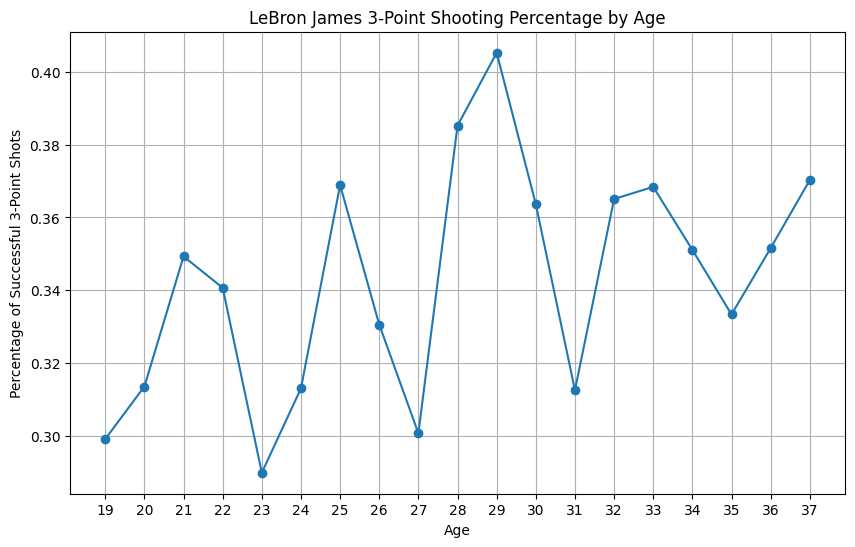

In [19]:
# prompt: create plot which compare each ages (19 , 20 , 21 , ... ) with percentage of that year and X is int age means 21 not 21.5 or etc

import matplotlib.pyplot as plt

# Assuming lebron_dataframe is already created from the previous code

plt.figure(figsize=(10, 6))
plt.plot(lebron_dataframe['Age'], lebron_dataframe['Percent_3P'], marker='o')
plt.xlabel('Age')
plt.ylabel('Percentage of Successful 3-Point Shots')
plt.title('LeBron James 3-Point Shooting Percentage by Age')
plt.xticks(lebron_dataframe['Age'])  # Ensure all ages are shown on the x-axis
plt.grid(True)
plt.show()

In [73]:
# now time to add torch to our codes
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [74]:

# Scaling the data
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()


X = lebron_dataframe[['Age']].values
y = lebron_dataframe[['Percent_3P']].values

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# we split our data to train and test then convert them to tensor
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [75]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
      super(LinearRegressionModel , self).__init__()
      self.linear = nn.Linear(1 , 1)

    def forward(self , x):
      return self.linear(x)

model = LinearRegressionModel()

In [76]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters() , lr = 0.1)

In [81]:
epoche = 1000
for epoche in range(epoche):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    if (epoche + 1) % 100 == 0:
      print(f'Epoch [{epoche + 1}/{epoche}], Loss: {loss.item():.4f}')



Epoch [100/99], Loss: 0.0697
Epoch [200/199], Loss: 0.0647
Epoch [300/299], Loss: 0.0642
Epoch [400/399], Loss: 0.0641
Epoch [500/499], Loss: 0.0641
Epoch [600/599], Loss: 0.0641
Epoch [700/699], Loss: 0.0641
Epoch [800/799], Loss: 0.0641
Epoch [900/899], Loss: 0.0641
Epoch [1000/999], Loss: 0.0641


In [82]:
# Evaluate the model
model.eval()
with torch.no_grad():
    predictions = model(X_test)
    predictions_unscaled = scaler_y.inverse_transform(predictions.numpy())
    y_test_unscaled = scaler_y.inverse_transform(y_test.numpy())


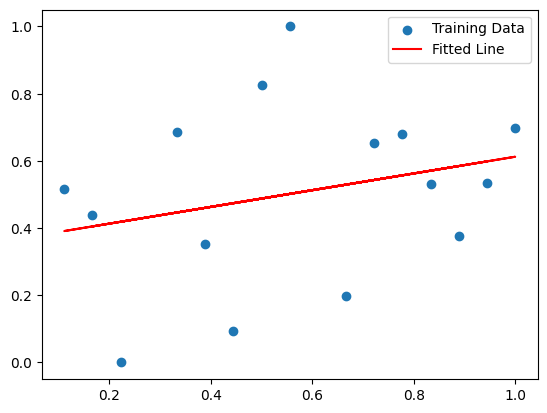

In [83]:
# Step 7: Visualize Training Results
with torch.no_grad():
    predicted = model(X_train).numpy()
plt.scatter(X_train.numpy(), y_train.numpy(), label='Training Data')
plt.plot(X_train.numpy(), predicted, color='red', label='Fitted Line')
plt.legend()
plt.show()


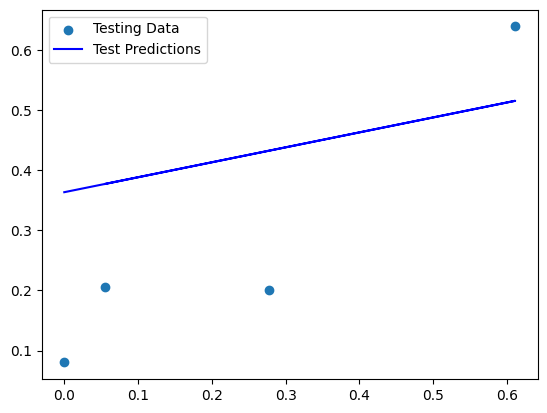

In [84]:
# Step 8: Visualize Testing Results
with torch.no_grad():
    test_predicted = model(X_test).numpy()
plt.scatter(X_test.numpy(), y_test.numpy(), label='Testing Data')
plt.plot(X_test.numpy(), test_predicted, color='blue', label='Test Predictions')
plt.legend()
plt.show()

In [ ]:
# we want to go throw Polynomial regrassion and update our models